# 14｜卷積神經網路_影像特徵與架構

手算與程式同時檢查 2D 互相關、ReLU 與最大池化。

對應 `slides/14_卷積神經網路_影像特徵與架構.md`；從第一格依序執行即可重現投影片中的表格與圖。

## 來源與改編界線

- Aurélien Géron，`handson-mlp/12_deep_computer_vision_with_cnns.ipynb`，固定 commit `47eba45aacc85feae51ba7db68dd1ca66cb25e0a`，參考 Cells 20–61（卷積與池化）。

- `MachineLearning2025/06_ANN_from_Scratch_MNIST.py`，固定 commit `3da2cb56b9efd17d7cd34602589f392554b40603`。
- 本 Notebook 為課堂短實驗：保留核心張量、演算法或評估流程，改用 NumPy／scikit-learn 與小型資料，讓 CPU 能快速重跑。
- 圖表與數值是本檔實際執行結果，不代表原書完整模型成效。原始程式授權與歸屬見 `../NOTICE.md`。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlcourse.common import SEED, setup, savefig, report
setup()
rng = np.random.default_rng(SEED)

## 課堂小實驗

In [2]:
X = np.array([[1, 2, 0], [0, 1, 3], [2, 1, 0]], dtype=float)
K = np.array([[1, 0], [0, -1]], dtype=float)
Y = np.empty((2, 2))
for i in range(2):
    for j in range(2):
        Y[i, j] = np.sum(X[i:i+2, j:j+2] * K)  # 深度學習框架採互相關慣例
relu = np.maximum(Y, 0)
pooled = relu.max()
print('cross-correlation output:\n', Y)
print('after ReLU:', relu.tolist(), ' max pool:', pooled)

cross-correlation output:
 [[ 0. -1.]
 [-1.  1.]]
after ReLU: [[0.0, 0.0], [0.0, 1.0]]  max pool: 1.0


## 執行結果圖

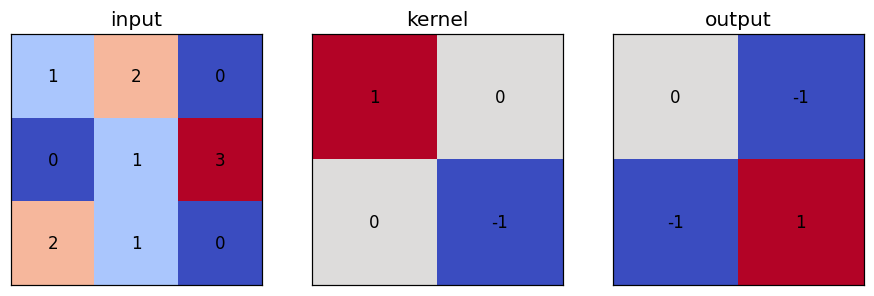

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, arr, title in zip(axes, [X, K, Y], ['input', 'kernel', 'output']):
    im = ax.imshow(arr, cmap='coolwarm'); ax.set_title(title)
    for (i, j), value in np.ndenumerate(arr): ax.text(j, i, f'{value:g}', ha='center', va='center')
    ax.set_xticks([]); ax.set_yticks([])
savefig('14_convolution_demo')
report('convolution_demo', {'output': Y.tolist(), 'relu': relu.tolist(), 'max_pool': pooled})

## 解讀與延伸

先描述圖或表直接支持的結果，再說明這個縮編實驗不能代表完整模型的哪些面向。